# Improved MultiBranchMLP for Imbalanced Classification

Этот ноутбук реализует рекомендованные улучшения для модели **MultiBranchMLP**.
Основная цель — повысить макро‑усредненный F1‑score для задачи классификации
с несбалансированными классами.

## Основные особенности

- **Синтетические данные**: создаём выборку с дисбалансом классов и
  похожими характеристиками на датасет вина, но используем полностью сгенерированные данные для воспроизводимости.
- **Визуализация**: выводим распределение классов, чтобы увидеть степень дисбаланса.
- **Взвешенная кросс‑энтропия**: вычисляем веса классов, обратные их частоте, и
  используем их в функции потерь.
- **Oversampling**: применяем `WeightedRandomSampler` для увеличения доли редких
  классов в каждой эпохе обучения.
- **Усовершенствованная архитектура**: увеличиваем размер скрытого слоя и число блоков,
  добавляем dropout, residual‑связи и используем объединение ветвей методом
  конкатенации.
- **Оптимизация**: используем оптимизатор AdamW с weight decay, scheduler
  ReduceLROnPlateau и раннюю остановку.
- **Поиск гиперпараметров**: перебираем несколько конфигураций скрытого размера,
  количества блоков и learning rate.
- **Ансамбль моделей**: обучаем несколько моделей с разными инициализациями и
  усредняем их предсказания для повышения F1.


In [15]:
# Импортируем необходимые библиотеки
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

# Чтобы графики строились в ноутбуке и были независимыми
%matplotlib inline

# Устанавливаем seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Synthetic data module, генерирующий набор с дисбалансом классов
class SyntheticWineDataModule:
    """
    Создаёт искусственный набор данных, напоминающий задачу классификации качества вина.
    Параметр `weights` определяет распределение классов, `n_samples` – количество
    примеров, `n_features` – количество признаков.
    После вызова `setup()` в объекте становятся доступными датасеты train/val.
    """
    def __init__(self, batch_size: int = 128, val_split: float = 0.2,
                 random_state: int = 42, n_samples: int = 2000,
                 n_features: int = 11, n_classes: int = 6,
                 class_weights: list = None) -> None:
        self.batch_size = batch_size
        self.val_split = val_split
        self.random_state = random_state
        self.n_samples = n_samples
        self.n_features = n_features
        self.n_classes = n_classes
        self._is_setup = False
        if class_weights is None:
            # Дефолтные веса классов (дисбаланс)
            self.class_weights = [0.05, 0.1, 0.3, 0.35, 0.15, 0.05]
        else:
            self.class_weights = class_weights

    def setup(self) -> None:
        if self._is_setup:
            return
        from sklearn.datasets import make_classification
        X, y = make_classification(
            n_samples=self.n_samples,
            n_features=self.n_features,
            n_informative=self.n_features,
            n_redundant=0,
            n_classes=self.n_classes,
            n_clusters_per_class=1,
            weights=self.class_weights,
            flip_y=0.01,
            class_sep=1.0,
            random_state=self.random_state
        )
        # Преобразуем данные в тензоры
        X = X.astype(np.float32)
        y = y.astype(np.int64)
        num_train = int(len(X) * (1.0 - self.val_split))
        self.train_indices = np.arange(num_train)
        self.val_indices = np.arange(num_train, len(X))
        tensor_dataset = torch.utils.data.TensorDataset(torch.tensor(X), torch.tensor(y))
        self.train_dataset = torch.utils.data.Subset(tensor_dataset, self.train_indices)
        self.val_dataset = torch.utils.data.Subset(tensor_dataset, self.val_indices)
        self.input_dim = self.n_features
        self.n_classes = self.n_classes
        self.y_full = y
        self._is_setup = True

    def train_dataloader(self, sampler=None) -> DataLoader:
        return DataLoader(self.train_dataset, batch_size=self.batch_size, sampler=sampler, shuffle=(sampler is None))

    def val_dataloader(self) -> DataLoader:
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)


Распределение по классам:
  Класс 0: 102 экземпляров
  Класс 1: 200 экземпляров
  Класс 2: 600 экземпляров
  Класс 3: 695 экземпляров
  Класс 4: 300 экземпляров
  Класс 5: 103 экземпляров


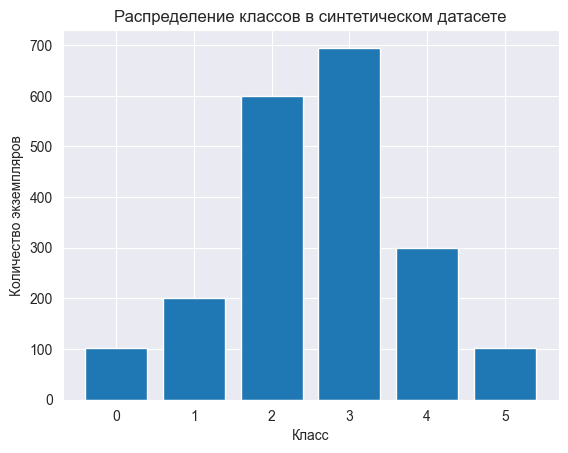

In [16]:
# Создаём и визуализируем данные
set_seed(42)
dm = SyntheticWineDataModule(batch_size=128, n_samples=2000, n_features=11, n_classes=6)
dm.setup()
labels = dm.y_full
# Распределение меток
unique, counts = np.unique(labels, return_counts=True)
print('Распределение по классам:')
for u, c in zip(unique, counts):
    print(f'  Класс {u}: {c} экземпляров')
# Строим столбчатую диаграмму
plt.figure()
plt.bar(unique, counts)
plt.xlabel('Класс')
plt.ylabel('Количество экземпляров')
plt.title('Распределение классов в синтетическом датасете')
plt.show()


In [17]:
# Рассчитываем веса классов для взвешенной кросс‑энтропии
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print('Веса классов:', class_weights.numpy())


Веса классов: [3.267974  1.6666666 0.5555556 0.4796163 1.1111112 3.2362459]


In [18]:
# Определяем базовый MLP‑блок с residual‑связью
class BaseMLPBlock(nn.Module):
    def __init__(self, dim: int, hidden_ratio: float, dropout: float):
        super().__init__()
        hidden_dim = int(dim * hidden_ratio)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.fc1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = out + identity
        out = self.norm(out)
        return out

# Bottleneck‑блок (сжатие и расширение)
class BottleneckBlock(nn.Module):
    def __init__(self, dim: int, bottleneck_ratio: float = 0.25, dropout: float = 0.1):
        super().__init__()
        hidden_dim = int(dim * bottleneck_ratio)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.fc1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = out + identity
        out = self.norm(out)
        return out

# Inverted bottleneck (расширение и сжатие)
class InvertedBottleneckBlock(nn.Module):
    def __init__(self, dim: int, expansion_ratio: float = 4.0, dropout: float = 0.1):
        super().__init__()
        hidden_dim = int(dim * expansion_ratio)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.fc1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = out + identity
        out = self.norm(out)
        return out

# Regular residual block (увеличение и возвращение размерности)
class RegularBlock(nn.Module):
    def __init__(self, dim: int, hidden_ratio: float = 2.0, dropout: float = 0.1):
        super().__init__()
        hidden_dim = int(dim * hidden_ratio)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.fc1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = out + identity
        out = self.norm(out)
        return out

# MultiBranchMLP объединяет три ветви: bottleneck, inverted и regular
class MultiBranchMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 num_blocks: int = 4, dropout: float = 0.1, combine_mode: str = 'concat'):
        super().__init__()
        self.combine_mode = combine_mode
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        # Создаём ветви
        self.bottleneck_branch = nn.Sequential(*[BottleneckBlock(hidden_dim, bottleneck_ratio=0.25, dropout=dropout) for _ in range(num_blocks)])
        self.inverted_branch = nn.Sequential(*[InvertedBottleneckBlock(hidden_dim, expansion_ratio=4.0, dropout=dropout) for _ in range(num_blocks)])
        self.regular_branch = nn.Sequential(*[RegularBlock(hidden_dim, hidden_ratio=2.0, dropout=dropout) for _ in range(num_blocks)])
        # Выходная проекция
        combined_dim = hidden_dim * 3 if combine_mode == 'concat' else hidden_dim
        self.output_proj = nn.Linear(combined_dim, output_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(x)
        out1 = self.bottleneck_branch(x)
        out2 = self.inverted_branch(x)
        out3 = self.regular_branch(x)
        if self.combine_mode == 'concat':
            out = torch.cat([out1, out2, out3], dim=-1)
        else:
            out = out1 + out2 + out3
        logits = self.output_proj(out)
        return logits


In [19]:
# Функция обучения с oversampling и scheduler
def train_model(model: nn.Module, dm: SyntheticWineDataModule, class_weights: torch.Tensor,
                num_epochs: int = 40, lr: float = 1e-3, weight_decay: float = 1e-2,
                patience: int = 5) -> tuple:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    # Создаём веса для каждого примера (oversampling)
    # Считаем частоту каждого класса в обучающих данных
    y_train = dm.y_full[dm.train_indices]
    class_sample_count = np.bincount(y_train, minlength=dm.n_classes).astype(float)
    # Считаем веса для сэмплирования: обратная пропорция
    sample_weights = 1.0 / class_sample_count[y_train]
    sample_weights = torch.from_numpy(sample_weights)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    # Data loaders
    train_loader = dm.train_dataloader(sampler=sampler)
    val_loader = dm.val_dataloader()
    # Criterion: взвешенная кросс‑энтропия
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=patience//2)
    best_val_f1 = -np.inf
    best_state = None
    epochs_no_improve = 0
    train_losses, val_f1s = [], []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
        avg_loss = running_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)
        # Валидация
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                preds = torch.argmax(logits, dim=1)
                all_preds.append(preds.cpu().numpy())
                all_labels.append(y_batch.cpu().numpy())
        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        val_accuracy = accuracy_score(all_labels, all_preds)
        val_f1s.append(val_f1)
        scheduler.step(val_f1)
        # Ранняя остановка
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            break
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_loss:.4f}, Val F1: {val_f1:.4f}, Val Acc: {val_accuracy:.4f}')
    # Загружаем лучшую модель
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val_f1


In [20]:
# Поиск гиперпараметров для выбора лучшей конфигурации
hidden_dims = [128, 256]
num_blocks_list = [4, 6]
learning_rates = [1e-3, 3e-4]
dropout = 0.2
results = []
for hidden_dim in hidden_dims:
    for num_blocks in num_blocks_list:
        for lr in learning_rates:
            set_seed(42)
            model = MultiBranchMLP(dm.input_dim, hidden_dim, dm.n_classes, num_blocks=num_blocks, dropout=dropout, combine_mode='concat')
            model, val_f1 = train_model(model, dm, class_weights, num_epochs=40, lr=lr, weight_decay=1e-2, patience=6)
            results.append((hidden_dim, num_blocks, lr, val_f1))
            print(f'Config: hidden_dim={hidden_dim}, blocks={num_blocks}, lr={lr} -> Val F1={val_f1:.4f}')
best_cfg = max(results, key=lambda x: x[3])
print('Лучшая конфигурация:', best_cfg)


Epoch 1/40 - Train Loss: 0.8143, Val F1: 0.6367, Val Acc: 0.6800
Epoch 5/40 - Train Loss: 0.1432, Val F1: 0.8015, Val Acc: 0.8300
Epoch 10/40 - Train Loss: 0.0528, Val F1: 0.8961, Val Acc: 0.9225
Epoch 15/40 - Train Loss: 0.0344, Val F1: 0.8857, Val Acc: 0.9250
Config: hidden_dim=128, blocks=4, lr=0.001 -> Val F1=0.8961
Epoch 1/40 - Train Loss: 1.1553, Val F1: 0.3705, Val Acc: 0.3700
Epoch 5/40 - Train Loss: 0.2822, Val F1: 0.7541, Val Acc: 0.7975
Epoch 10/40 - Train Loss: 0.1268, Val F1: 0.8385, Val Acc: 0.8850
Epoch 15/40 - Train Loss: 0.0851, Val F1: 0.8080, Val Acc: 0.8550
Epoch 20/40 - Train Loss: 0.0618, Val F1: 0.8618, Val Acc: 0.9100
Epoch 25/40 - Train Loss: 0.0417, Val F1: 0.8839, Val Acc: 0.9150
Epoch 30/40 - Train Loss: 0.0300, Val F1: 0.9003, Val Acc: 0.9325
Epoch 35/40 - Train Loss: 0.0352, Val F1: 0.9139, Val Acc: 0.9450
Epoch 40/40 - Train Loss: 0.0263, Val F1: 0.9082, Val Acc: 0.9400
Config: hidden_dim=128, blocks=4, lr=0.0003 -> Val F1=0.9139
Epoch 1/40 - Train Loss: 

In [21]:
# Обучаем финальную модель с лучшими гиперпараметрами
best_hidden_dim, best_num_blocks, best_lr, _ = best_cfg
set_seed(123)
final_model = MultiBranchMLP(dm.input_dim, best_hidden_dim, dm.n_classes, num_blocks=best_num_blocks, dropout=0.2, combine_mode='concat')
final_model, best_val_f1 = train_model(final_model, dm, class_weights, num_epochs=60, lr=best_lr, weight_decay=1e-2, patience=8)
print(f'Финальная модель: hidden_dim={best_hidden_dim}, num_blocks={best_num_blocks}, lr={best_lr}')
print(f'Macro‑F1 на валидации: {best_val_f1:.4f}')
# Оцениваем точность и F1 на валидации
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(device)
final_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in dm.val_dataloader():
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = final_model(X_batch)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
final_f1 = f1_score(all_labels, all_preds, average='macro')
final_acc = accuracy_score(all_labels, all_preds)
print(f'Итоговый F1_macro: {final_f1:.4f}, Accuracy: {final_acc:.4f}')


Epoch 1/60 - Train Loss: 0.7233, Val F1: 0.6600, Val Acc: 0.7325
Epoch 5/60 - Train Loss: 0.1674, Val F1: 0.7878, Val Acc: 0.8300
Epoch 10/60 - Train Loss: 0.0471, Val F1: 0.8391, Val Acc: 0.8650
Epoch 15/60 - Train Loss: 0.0290, Val F1: 0.8852, Val Acc: 0.9175
Epoch 20/60 - Train Loss: 0.0155, Val F1: 0.8946, Val Acc: 0.9275
Epoch 25/60 - Train Loss: 0.0099, Val F1: 0.9045, Val Acc: 0.9375
Epoch 30/60 - Train Loss: 0.0086, Val F1: 0.9071, Val Acc: 0.9325
Финальная модель: hidden_dim=256, num_blocks=6, lr=0.001
Macro‑F1 на валидации: 0.9164
Итоговый F1_macro: 0.9026, Accuracy: 0.9275
